In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("/home/dynamics/bikram/BioHasher/results/ApproxNearestNeighbourResults_SubseqHash-64.csv")

In [3]:
df

,b,r,Avg_Recall,Avg_Precision,Avg_FPR,Avg_F1_Score
0,1,1,0.480000,0.446667,0.000140,0.462712
1,1,2,0.576667,0.481389,0.000340,0.524681
2,1,3,0.660000,0.541167,0.000434,0.594155
3,1,4,0.713333,0.538556,0.000677,0.613614
4,1,5,0.763333,0.541222,0.000791,0.633153
5,2,1,0.293333,0.293333,0.000000,0.293333
6,2,2,0.376667,0.376667,0.000000,0.376667
7,2,3,0.413333,0.413333,0.000000,0.413333
8,2,4,0.496667,0.496667,0.000000,0.496667
9,2,5,0.486667,0.486667,0.000000,0.486667


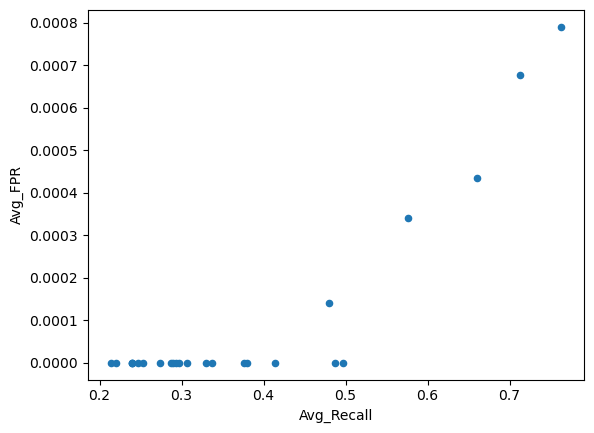

In [7]:
df.plot.scatter(x='Avg_Recall', y='Avg_FPR', alpha=1)
plt.show()

<Axes: xlabel='Avg_Recall', ylabel='Avg_FPR'>

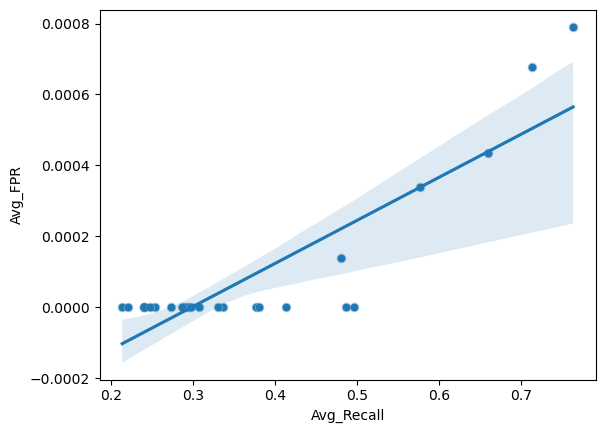

In [6]:
import seaborn as sns

# Basic scatter
sns.scatterplot(data=df, x="Avg_Recall", y='Avg_FPR')

# With a linear regression fit (OLS)
sns.regplot(data=df, x='Avg_Recall', y='Avg_FPR', scatter_kws={'alpha':0.3})

In [17]:
x_axis = {0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1.0}

In [18]:
gen = np.random.RandomState(42)
num_perm = 128
_mersenne_prime = np.uint64((1 << 61) - 1)
display(np.array([( gen.randint(1, _mersenne_prime, dtype=np.uint64), gen.randint(0, _mersenne_prime, dtype=np.uint64),) for _ in range(num_perm)],dtype=np.uint64,).T)

array([[2297359619001564596, 1973689801170867272,  572192888165898362,
        1071453510346823115, 1865242737500154728,  379716980844854581,
        1520798217888136606, 1048235628103308220, 1000592739665268026,
        1050450229337746265, 2063321781277379071,  777431531920034492,
        1495477363401685950, 1377488174878099308, 1704747971477620217,
        1983852346201383559, 1199990111390225682, 1671865959972055054,
        1007446255075745114, 1092656530294298716, 2251208029941317036,
         634356285132873763,  161962062168655410, 1138368374822601726,
         861652531725782788, 1744778438383761810, 1189795419742834890,
        1805935812952358751, 1632398491907562958,  834296198785359550,
         252301427447193325, 1452450688103961368,  570641018389960892,
         293750097594324125, 1375216642409152345,  410343612402300033,
         101865178233748543, 1510001446519210376,  392368560994791803,
        2000839474307464186, 2086389863579132105, 1492305152117099553,
      

In [19]:
def update(self, b) -> None:
    hv = self.hashfunc(b)  # Hash the input
    a, b = self.permutations  # Get permutation parameters
    phv = np.bitwise_and((a * hv + b) % _mersenne_prime, _max_hash)  # Apply permutations
    self.hashvalues = np.minimum(phv, self.hashvalues)  # Keep minimum values

In [2]:
def read_collision_data_complete(filename):
	"""
    Read collision results CSV file with proper metadata parsing
    """
	with open(filename, 'r') as file:
		lines = file.readlines()

		sections = {}
		data_lines = []
		subdata_i = 0

		for i,line in enumerate(lines):
			if line.startswith(':'):
				subdata_i = 0
				# This is a metadata line
				if line.startswith(':1:'):
					sections['test_name'] = line[3:].strip()
					# print(f"Line {i+1} - Name: {sections['test_name']}")
				elif line.startswith(':2:'):
					continue
				elif line.startswith(':3:'):
					line_content = line[3:].strip()
					line_parts = line_content.split(',')
					sections['Hashname'] = line_parts[0].strip()
					sections['Keybits'] = int(line_parts[1].strip())
					sections['Tokenlength'] = int(line_parts[2].strip())
					# print(f"Line {i+1} - Hash Info: {sections['Hashname']}, {sections['Keybits']}, {sections['Tokenlength']}")
				elif line.startswith(':4:'):
					line_content = line[3:].strip()
					similarity_rates = [float(x.strip()) for x in line_content.split(',')]
					sections['similarity_rates'] = similarity_rates
					# print(f"Line {i+1} - Similarity Rates: {sections['similarity_rates']}")
				elif line.startswith(':5:'):
					continue
				elif line.startswith(':6:'):
					continue
			else:
				if line:
					collision_counts = [float(x) for x in line.split(',')]
					# Create a row with metadata + data
					row_data = {
						'test_name': sections.get('test_name', ''),
						'hashname': sections.get('Hashname', ''),
						'keybits': sections.get('Keybits', 0),
						'tokenlength': sections.get('Tokenlength', 0),
						'similarity_rate': sections.get('similarity_rates', [])[subdata_i],
						'collision_counts': collision_counts
					}
					subdata_i += 1
					# This is a data line
					data_lines.append(row_data)
	return sections, pd.DataFrame(data_lines)

In [5]:
# Usage
filename = '/home/dynamics/bikram/BioHasher/extras/results/collisionResults_SimHash-32-encoded.csv'
sections,data_lines = read_collision_data_complete(filename)
data_lines['average_collisions'] = data_lines['collision_counts'].apply(np.mean)
data_lines['std_dev_collisions'] = data_lines['collision_counts'].apply(np.std)


# print(f"\nProcessed {len(data_rows)} data rows")
# print("Sample row:", data_rows[0] if data_rows else "No data rows found")

Creating 1 subplots, each with 1 graphs
Unique keybits: [2048]
Unique tokenlengths: [19]


AttributeError: 'numpy.ndarray' object has no attribute 'plot'

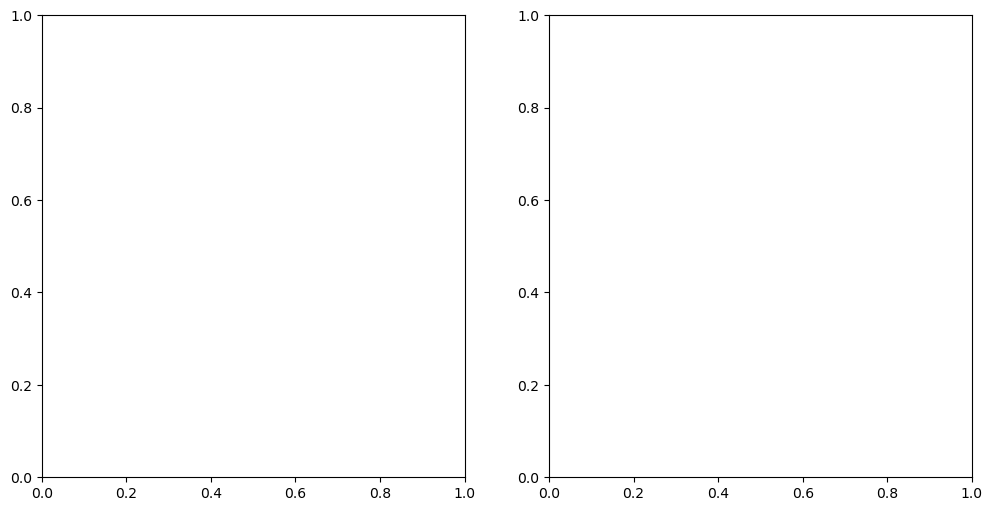

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique values for subplot organization
unique_keybits = sorted(data_lines['keybits'].unique())
unique_tokenlengths = sorted(data_lines['tokenlength'].unique())

n_keybits = len(unique_keybits)
n_tokenlengths = len(unique_tokenlengths)

print(f"Creating {n_keybits} subplots, each with {n_tokenlengths} graphs")
print(f"Unique keybits: {unique_keybits}")
print(f"Unique tokenlengths: {unique_tokenlengths}")


# Create subplots
# Calculate rows and columns for 2 subplots per row
n_cols = 2
n_rows = (n_keybits + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6*n_rows))


# Handle different subplot configurations
if n_keybits == 1:
    axes = [axes] if n_rows == 1 else axes.flatten()
elif n_rows == 1:
    axes = axes if n_keybits > 1 else [axes]
else:
    axes = axes.flatten()

# Define colors for different token lengths
colors = plt.cm.Set1(np.linspace(0, 1, n_tokenlengths))

# Plot data
for i, keybit in enumerate(unique_keybits):
    ax = axes[i]
    
    for j, tokenlength in enumerate(unique_tokenlengths):
        # Filter data for this specific keybit and tokenlength combination
        subset = data_lines[
            (data_lines['keybits'] == keybit) & 
            (data_lines['tokenlength'] == tokenlength)
        ]
        
        if not subset.empty:
            # Plot similarity_rate vs average_collisions
            ax.plot(subset['similarity_rate'], subset['average_collisions'], 
                   marker='o', color=colors[j], linewidth=2, markersize=6,
                   label=f'Token Length {tokenlength}')
    
    # Customize subplot
    ax.set_xlabel('Similarity Rate', fontsize=12)
    ax.set_ylabel('Average Collisions', fontsize=12)
    ax.set_title(f'Keybits = {keybit}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.9)
    ax.legend()
    
    # Set x-axis limits to match your data range
    ax.set_xlim(0, 1)

# Hide unused subplots if n_keybits is odd
if n_keybits < len(axes):
    for i in range(n_keybits, len(axes)):
        axes[i].set_visible(False)

# Overall plot formatting
fig.suptitle(f'LSH Collision Analysis: {data_lines["hashname"].iloc[0]}', 
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print summary statistics
# print("\nSummary Statistics:")
# for keybit in unique_keybits:
#     print(f"\nKeybits = {keybit}:")
#     for tokenlength in unique_tokenlengths:
#         subset = data_lines[
#             (data_lines['keybits'] == keybit) & 
#             (data_lines['tokenlength'] == tokenlength)
#         ]
#         if not subset.empty:
#             avg_col_mean = subset['average_collisions'].mean()
#             avg_col_std = subset['average_collisions'].std()
#             print(f"  Token Length {tokenlength}: Mean={avg_col_mean:.2f}, Std={avg_col_std:.2f}")

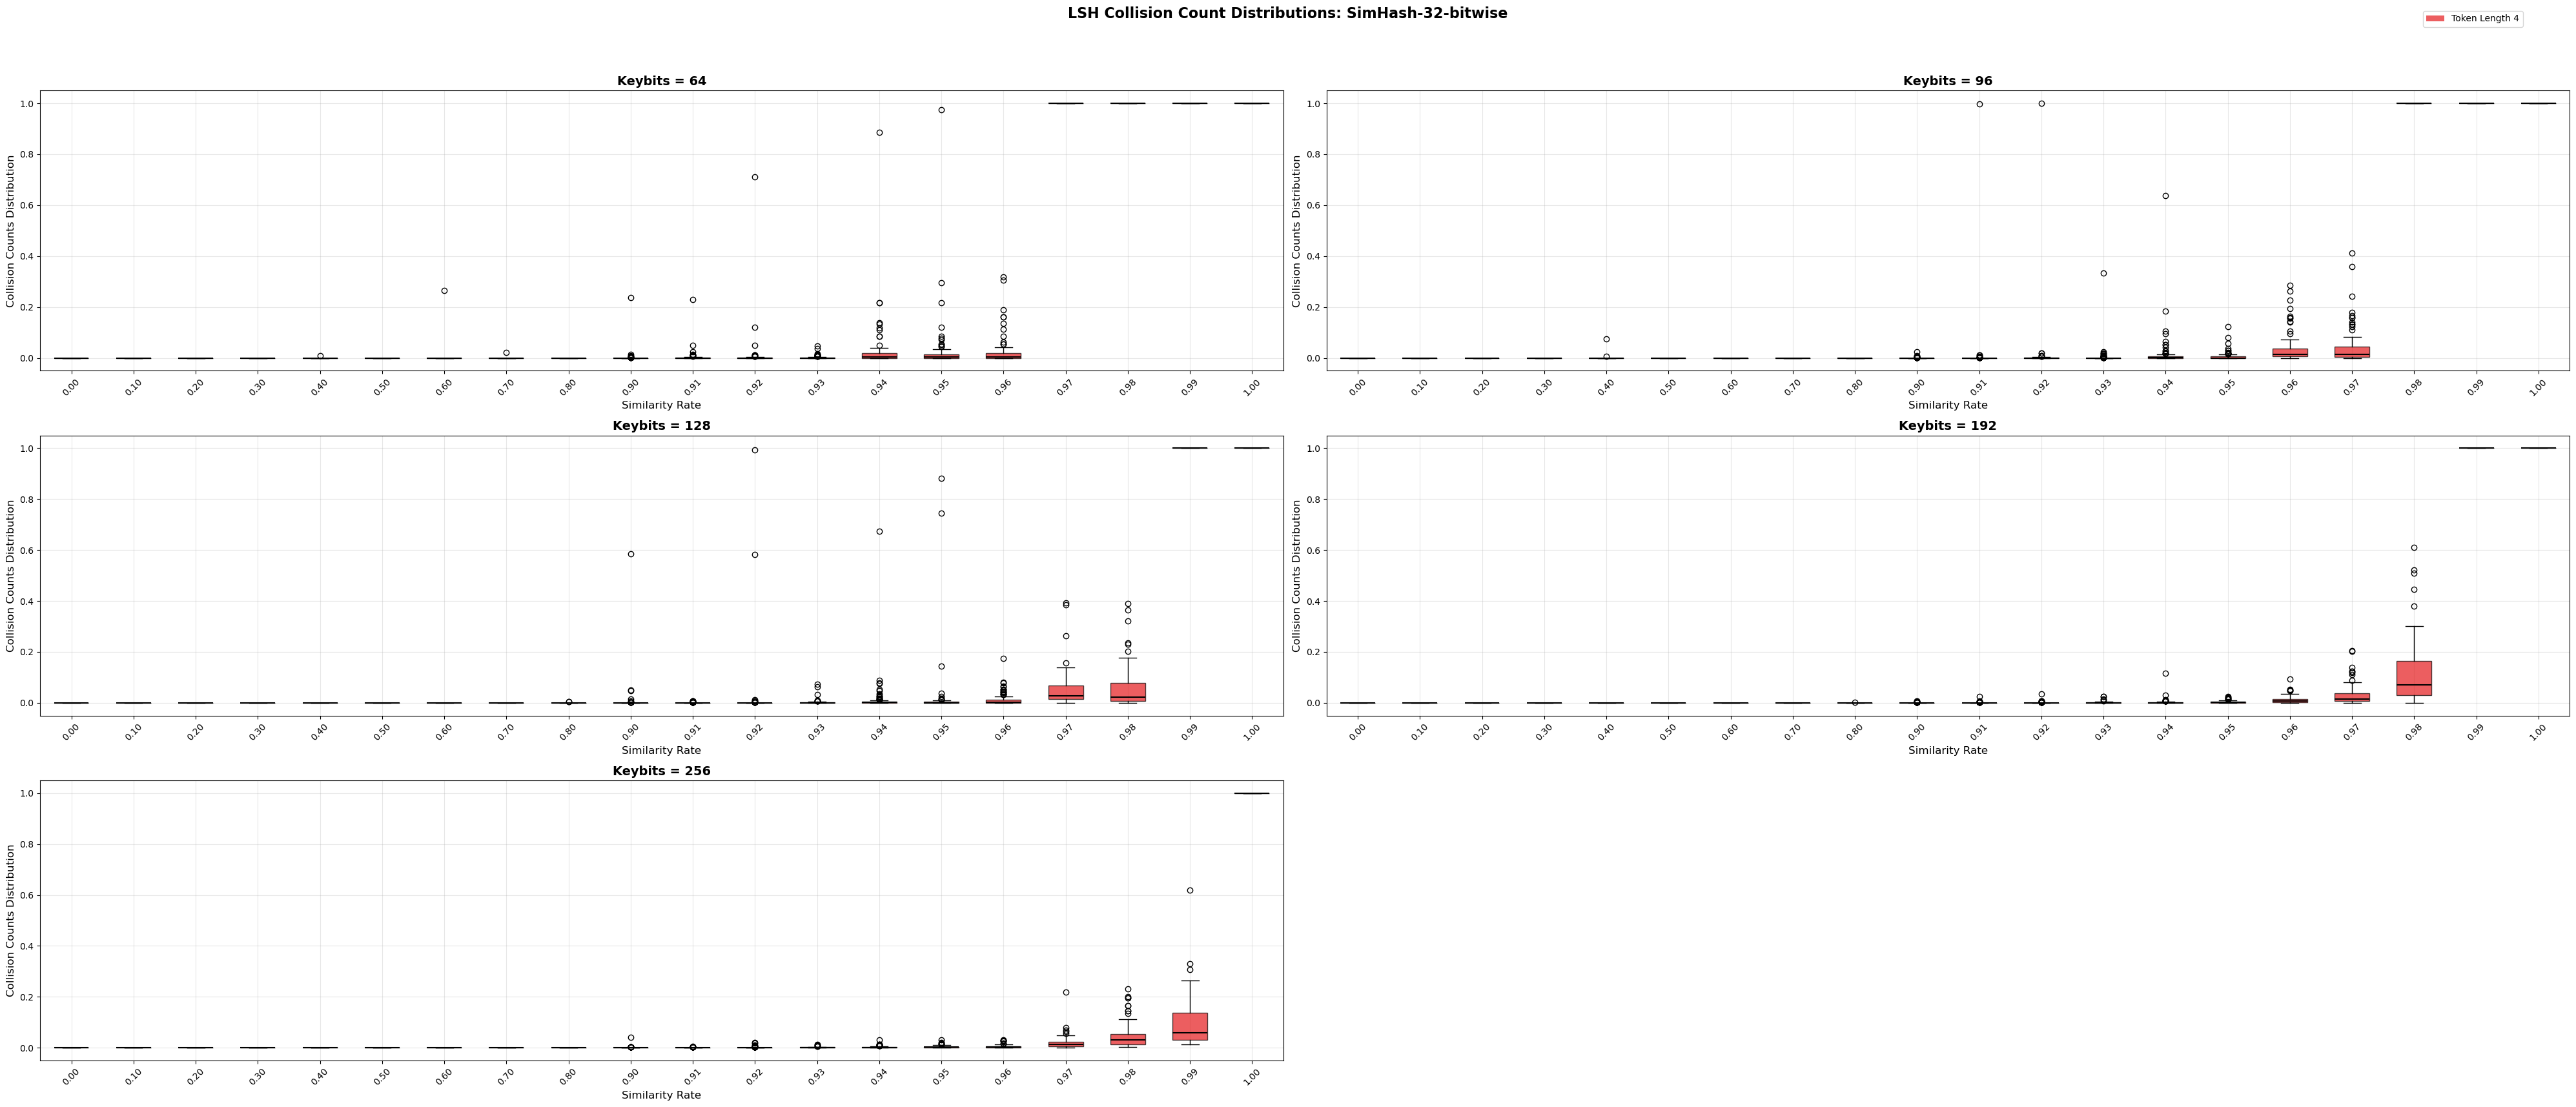

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique values for subplot organization
unique_keybits = sorted(data_lines['keybits'].unique())
unique_tokenlengths = sorted(data_lines['tokenlength'].unique())

n_keybits = len(unique_keybits)
n_tokenlengths = len(unique_tokenlengths)

# Calculate rows and columns for 2 subplots per row
n_cols = 2
n_rows = (n_keybits + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 6*n_rows))

# Handle subplot configurations
if n_keybits == 1:
    axes = [axes] if n_rows == 1 else axes.flatten()
elif n_rows == 1:
    axes = axes if n_keybits > 1 else [axes]
else:
    axes = axes.flatten()

# Define colors
colors = plt.cm.Set1(np.linspace(0, 1, n_tokenlengths))

# Plot data
for i, keybit in enumerate(unique_keybits):
    ax = axes[i]
    
    # Get all unique similarity rates for this keybit
    all_sim_rates = set()
    for tokenlength in unique_tokenlengths:
        subset = data_lines[
            (data_lines['keybits'] == keybit) & 
            (data_lines['tokenlength'] == tokenlength)
        ]
        if not subset.empty:
            all_sim_rates.update(subset['similarity_rate'].unique())
    
    unique_sim_rates = sorted(all_sim_rates)
    
    # For each similarity rate, create grouped box plots
    for sim_idx, sim_rate in enumerate(unique_sim_rates):
        box_data = []
        colors_for_this_group = []
        
        for j, tokenlength in enumerate(unique_tokenlengths):
            subset = data_lines[
                (data_lines['keybits'] == keybit) & 
                (data_lines['tokenlength'] == tokenlength) &
                (data_lines['similarity_rate'] == sim_rate)
            ]
            
            if not subset.empty:
                # Get collision counts for this combination
                collision_counts = subset['collision_counts'].iloc[0]
                box_data.append(collision_counts)
                colors_for_this_group.append(colors[j])
            else:
                # Add empty data to maintain alignment
                box_data.append([])
                colors_for_this_group.append(colors[j])
        
        # Create positions for this group of box plots
        if box_data:
            # Calculate positions: center around sim_idx, with small offsets for each token length
            group_width = 0.8
            box_width = group_width / n_tokenlengths
            positions = []
            
            for j in range(n_tokenlengths):
                offset = (j - (n_tokenlengths - 1) / 2) * box_width
                positions.append(sim_idx + offset)
            
            # Filter out empty data
            valid_data = [(data, pos, color) for data, pos, color in 
                         zip(box_data, positions, colors_for_this_group) if data]
            
            if valid_data:
                valid_box_data, valid_positions, valid_colors = zip(*valid_data)
                
                # Create box plot
                bp = ax.boxplot(valid_box_data, positions=valid_positions, 
                               widths=box_width*0.7, patch_artist=True,
                               boxprops=dict(linewidth=1),
                               medianprops=dict(color='black', linewidth=1.5),
                               whiskerprops=dict(linewidth=1),
                               capprops=dict(linewidth=1))
                
                # Color the boxes
                for patch, color in zip(bp['boxes'], valid_colors):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
    
    # Customize subplot
    ax.set_xlabel('Similarity Rate', fontsize=12)
    ax.set_ylabel('Collision Counts Distribution', fontsize=12)
    ax.set_title(f'Keybits = {keybit}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Set x-ticks and labels
    ax.set_xticks(range(len(unique_sim_rates)))
    ax.set_xticklabels([f'{rate:.2f}' for rate in unique_sim_rates], rotation=45)
    ax.set_xlim(-0.5, len(unique_sim_rates) - 0.5)

# Create legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[j], alpha=0.7, 
                                label=f'Token Length {tokenlength}') 
                  for j, tokenlength in enumerate(unique_tokenlengths)]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

# Hide unused subplots
if n_keybits < len(axes):
    for i in range(n_keybits, len(axes)):
        axes[i].set_visible(False)

# Overall formatting
fig.suptitle(f'LSH Collision Count Distributions: {data_lines["hashname"].iloc[0]}', 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'boxplot'

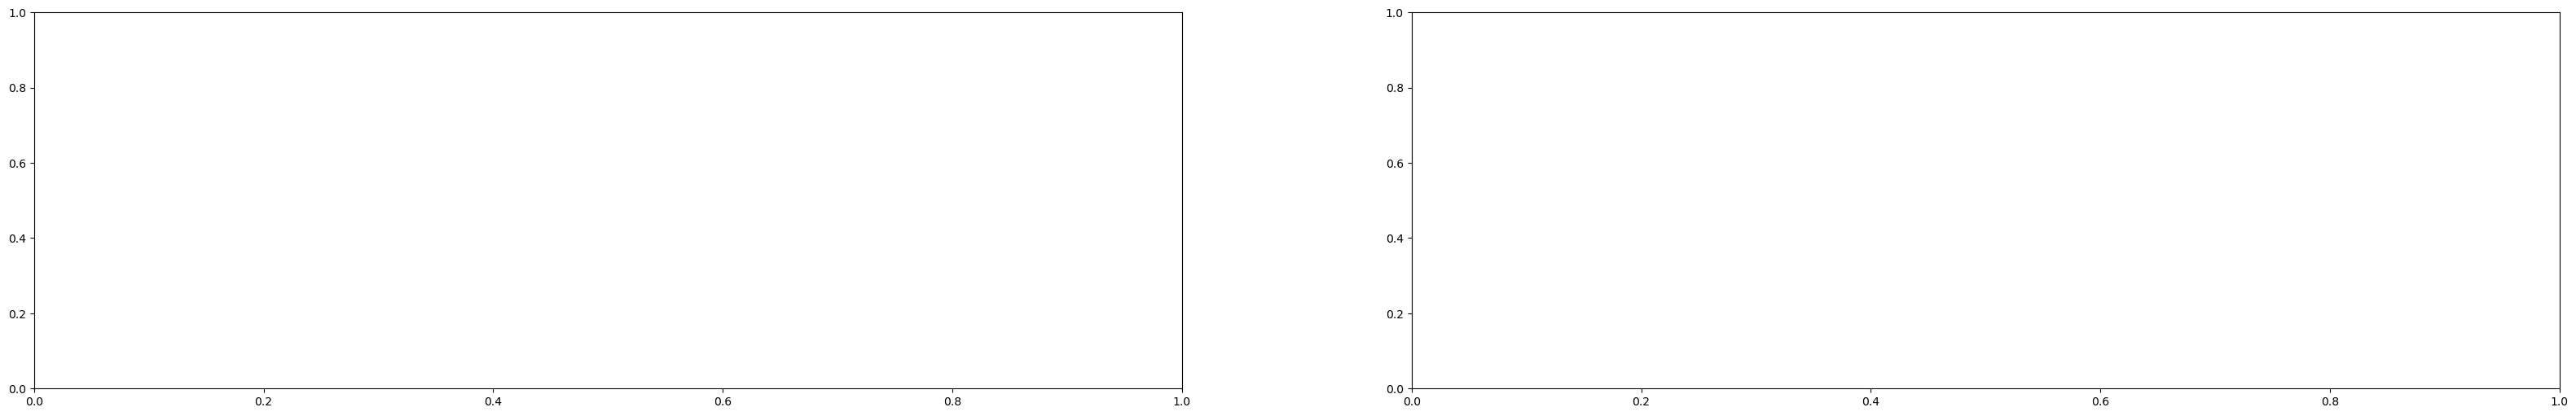

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique values for subplot organization
unique_keybits = sorted(data_lines['keybits'].unique())
unique_tokenlengths = sorted(data_lines['tokenlength'].unique())

n_keybits = len(unique_keybits)
n_tokenlengths = len(unique_tokenlengths)

# Calculate rows and columns for 2 subplots per row
n_cols = 2
n_rows = (n_keybits + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 6*n_rows))

# Handle subplot configurations
if n_keybits == 1:
    axes = [axes] if n_rows == 1 else axes.flatten()
elif n_rows == 1:
    axes = axes if n_keybits > 1 else [axes]
else:
    axes = axes.flatten()

# Define colors
colors = plt.cm.Set1(np.linspace(0, 1, n_tokenlengths))

# Plot data
for i, keybit in enumerate(unique_keybits):
    ax = axes[i]
    
    # Get all unique similarity rates for this keybit
    all_sim_rates = set()
    for tokenlength in unique_tokenlengths:
        subset = data_lines[
            (data_lines['keybits'] == keybit) & 
            (data_lines['tokenlength'] == tokenlength)
        ]
        if not subset.empty:
            all_sim_rates.update(subset['similarity_rate'].unique())
    
    unique_sim_rates = sorted(all_sim_rates)
    
    # For each similarity rate, create grouped box plots
    for sim_rate in unique_sim_rates:
        box_data = []
        colors_for_this_group = []
        positions = []
        
        for j, tokenlength in enumerate(unique_tokenlengths):
            subset = data_lines[
                (data_lines['keybits'] == keybit) & 
                (data_lines['tokenlength'] == tokenlength) &
                (data_lines['similarity_rate'] == sim_rate)
            ]
            
            if not subset.empty:
                # Get collision counts for this combination
                collision_counts = subset['collision_counts'].iloc[0]
                box_data.append(collision_counts)
                colors_for_this_group.append(colors[j])
                
                # Use actual similarity rate as x-position with small offset
                offset_width = 0.01  # Small offset between token lengths
                offset = (j - (n_tokenlengths - 1) / 2) * offset_width
                positions.append(sim_rate + offset)
        
        # Create box plot with actual numerical positions
        if box_data and positions:
            bp = ax.boxplot(box_data, positions=positions, 
                           widths=0.008, patch_artist=True,  # Smaller width for better spacing
                           boxprops=dict(linewidth=1),
                           medianprops=dict(color='black', linewidth=1.5),
                           whiskerprops=dict(linewidth=1),
                           capprops=dict(linewidth=1))
            
            # Color the boxes
            for patch, color in zip(bp['boxes'], colors_for_this_group):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
    
    # Customize subplot
    ax.set_xlabel('Similarity Rate', fontsize=12)
    ax.set_ylabel('Collision Counts Distribution', fontsize=12)
    ax.set_title(f'Keybits = {keybit}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to use numerical values with proper spacing
    ax.set_xlim(-0.02, 1.02)
    
    # Set x-ticks to show the actual similarity rate values
    # Show more ticks in the dense region (0.9-1.0)
    major_ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    minor_ticks = [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
    
    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.set_xticklabels([f'{x:.1f}' for x in major_ticks])

# Create legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[j], alpha=0.7, 
                                label=f'Token Length {tokenlength}') 
                  for j, tokenlength in enumerate(unique_tokenlengths)]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

# Hide unused subplots
if n_keybits < len(axes):
    for i in range(n_keybits, len(axes)):
        axes[i].set_visible(False)

# Overall formatting
fig.suptitle(f'LSH Collision Count Distributions: {data_lines["hashname"].iloc[0]}', 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()